# Test beta evolution

## Principal Settings

In [2]:
# Standard library imports
import sys
import numpy as np
import pandas as pd

# Project-specific imports
sys.path.append('../src/')
from models.types import ModelConfig
from models.har import HARModel

data_path = '../data/processed/HAR/'

## Functions

In [5]:
def sanity_check_coins(list_of_coins):
    """
    Check:
    - number of observations
    - date coverage
    - missing days
    - missing values
    - common overlapping period

    Returns
    -------
    tuple[pd.Timestamp, pd.Timestamp]
        (common_start, common_end) across all coins.
    """

    print("\n===== SANITY CHECK =====")

    coin_date_ranges = {}

    for coin in list_of_coins:

        df = pd.read_parquet(data_path + f'{coin}_har.parquet')
        df = df.sort_index()

        n_obs = len(df)
        start_date = df.index.min()
        end_date = df.index.max()

        # Check missing calendar days
        full_range = pd.date_range(start=start_date, end=end_date, freq="D")
        missing_days = len(full_range.difference(df.index))

        # Check missing values
        n_missing_values = df.isna().sum().sum()

        print(f"\nCoin: {coin}")
        print(f"Observations: {n_obs}")
        print(f"Period: {start_date.date()} → {end_date.date()}")
        print(f"Missing calendar days: {missing_days}")
        print(f"Missing values inside dataset: {n_missing_values}")

        coin_date_ranges[coin] = (start_date, end_date)

    # Overlapping period
    max_start = max([v[0] for v in coin_date_ranges.values()])
    min_end = min([v[1] for v in coin_date_ranges.values()])

    print("\n===== COMMON OVERLAP PERIOD =====")
    print(f"Common start: {max_start.date()}")
    print(f"Common end:   {min_end.date()}")

    if max_start >= min_end:
        raise ValueError("No common overlapping period across all coins.")

    print("===== END SANITY CHECK =====\n")

    return max_start, min_end


def run_test_beta_evolution(
    coin,
    window_size=None,
    validation_window=100,
    loss_name="qlike"
):

    # -----------------------------
    # Sanity check first
    # -----------------------------
    common_start, common_end = sanity_check_coins([coin])

    if window_size is None:
        window_size = 1000

    detailed_results = []

    print(f"\nTesting window size: {window_size}")

    data_df = pd.read_parquet(data_path + f'{coin}_har.parquet')
    data_df = data_df.sort_index()
    data_df = data_df.loc[(data_df.index >= common_start) & (data_df.index <= common_end)]

    if data_df.empty:
        print(f"Skipping {coin}: no data in common overlap period.")
        return None, None, None

    X_full = data_df[["RV_d", "RV_w", "RV_m"]].values
    y_full = data_df["target"].values

    window_train_losses = []
    window_val_losses = []

    for end_idx in range(window_size, len(X_full) + 1):

        start_idx = end_idx - window_size

        X_window = X_full[start_idx:end_idx]
        y_window = y_full[start_idx:end_idx]

        X_subtrain = X_window[:-validation_window]
        y_subtrain = y_window[:-validation_window]

        X_val = X_window[-validation_window:]
        y_val = y_window[-validation_window:]

        if len(X_subtrain) <= 5:
            print(f"Skipping window ending at index {end_idx}: not enough training data.")
            return None, None, None

        config = ModelConfig(name=f"HAR_L{window_size}")
        model = HARModel(config)

        fit_result = model.fit(
            X_subtrain,
            y_subtrain,
            X_val=X_val,
            y_val=y_val,
            loss_fn=getattr(model, loss_name)
        )

        window_train_losses.append(fit_result.train_loss)
        window_val_losses.append(fit_result.val_loss)

        detailed_results.append({
            "coin": coin,
            "window_size": window_size,
            "window_end_date": data_df.index[end_idx - 1],
            "train_loss": fit_result.train_loss,
            "val_loss": fit_result.val_loss,
            "beta": model.beta[0],
            "beta_d": model.beta[1],
            "beta_w": model.beta[2],
            "beta_m": model.beta[3]
        })

    if len(window_val_losses) == 0:
        print(f"Skipping {coin}: no valid windows found.")
        return None, None, None

    result_df = pd.DataFrame(detailed_results)

    return result_df

## Runnings

### Over optimal window

In [3]:
result_path = "../results/test_betas_in_time/"

pair_coin_L = [("ADA", 800), ("BTC", 1150), ("ETH", 900), ("SOL", 1200), ("XRP", 700)]

# Experiment by coin
for coin_name, L in pair_coin_L:
    result_path_coin = result_path + f"{coin_name}/"
    result_df = run_test_beta_evolution(
        coin=coin_name,
        window_size=L,
        validation_window=100,
        loss_name="qlike"
    )
    result_df.to_csv(result_path_coin + "optimal_window.csv", index=False)


===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2018-05-16
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 800

===== SANITY CHECK =====

Coin: BTC
Observations: 3030
Period: 2017-09-15 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2017-09-15
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 1150

===== SANITY CHECK =====

Coin: ETH
Observations: 3030
Period: 2017-09-15 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2017-09-15
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 900

===== SANITY CHECK =====

Coin: SOL
Observations: 1940
Period: 2020-09-09 → 2025-12-31
Missing calendar days: 0
Missing values inside dat

### Over a grid of windows

In [9]:
result_path = "../results/test_betas_in_time/"

coin_names = ["ADA", "BTC" , "ETH", "SOL", "XRP"]

window_size_options = list(range(300, 1500, 50))

# Experiment by coin
for coin_name in coin_names:
    detailed_df = None
    result_path_coin = result_path + f"{coin_name}/"
    for L in window_size_options:
        result_df = run_test_beta_evolution(
            coin=coin_name,
            window_size=L,
            validation_window=100,
            loss_name="qlike"
        )

        if detailed_df is None:
            detailed_df = result_df
        else:
            detailed_df = pd.concat([detailed_df, result_df], ignore_index=True)
    detailed_df.to_csv(result_path_coin + "detailed_results.csv", index=False)


===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2018-05-16
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 300

===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2018-05-16
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 350

===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2018-05-16
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 400

===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside data

## Inspect results

### Functions

In [53]:
import matplotlib.pyplot as plt

def plot_betas(df, figsize=(12, 5), linewidth=1.5, title=None):
    required_cols = ["window_end_date", "beta", "beta_d", "beta_w", "beta_m"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df.copy()
    plot_df["window_end_date"] = pd.to_datetime(plot_df["window_end_date"], utc=True, errors="coerce")
    plot_df = plot_df.sort_values("window_end_date")

    fig, ax = plt.subplots(figsize=figsize)

    # Left axis: betas
    beta_cols = ["beta", "beta_d", "beta_w", "beta_m"]
    for col in beta_cols:
        ax.plot(plot_df["window_end_date"], plot_df[col], linewidth=linewidth, label=col)

    ax.set_xlabel("Window end date")
    ax.set_ylabel("Beta value")
    ax.grid(True, alpha=0.3)

    # Right axis: RV_d (different scale)
    ax2 = None
    if "RV_d" in plot_df.columns:
        ax2 = ax.twinx()
        ax2.plot(
            plot_df["window_end_date"],
            plot_df["RV_d"],
            color="black",
            linestyle="--",
            linewidth=linewidth,
            label="RV_d"
        )
        ax2.set_ylabel("RV_d")

        # Combined legend
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, title="Columns", loc="best")
    else:
        ax.legend(title="Columns", loc="best")

    ax.set_title(title if title else "Beta evolution")
    fig.tight_layout()
    return ax

In [48]:
import matplotlib.pyplot as plt

def plot_betas_by_window_size(df, agg="mean", figsize=(12, 12), linewidth=1.8, title=None):
    required_cols = ["coin", "window_size", "beta", "beta_d", "beta_w", "beta_m"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    value_cols = ["beta", "beta_d", "beta_w", "beta_m"]

    grouped = (
        df[required_cols]
        .groupby(["coin", "window_size"], as_index=False)[value_cols]
        .agg(agg)
        .sort_values(["coin", "window_size"])
    )

    coins = sorted(grouped["coin"].unique())
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)

    for ax, col in zip(axes, value_cols):
        for coin in coins:
            sub = grouped[grouped["coin"] == coin]
            ax.plot(
                sub["window_size"],
                sub[col],
                linewidth=linewidth,
                label=coin
            )
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("window_size")
    fig.suptitle(title if title else "Betas vs window_size by coin", y=0.995)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="coin", loc="upper right")
    plt.tight_layout()
    return fig, axes


### Results

In [50]:
import pandas as pd
import os

results_path = "../results/test_betas_in_time/"
data_path = '../data/processed/HAR/'

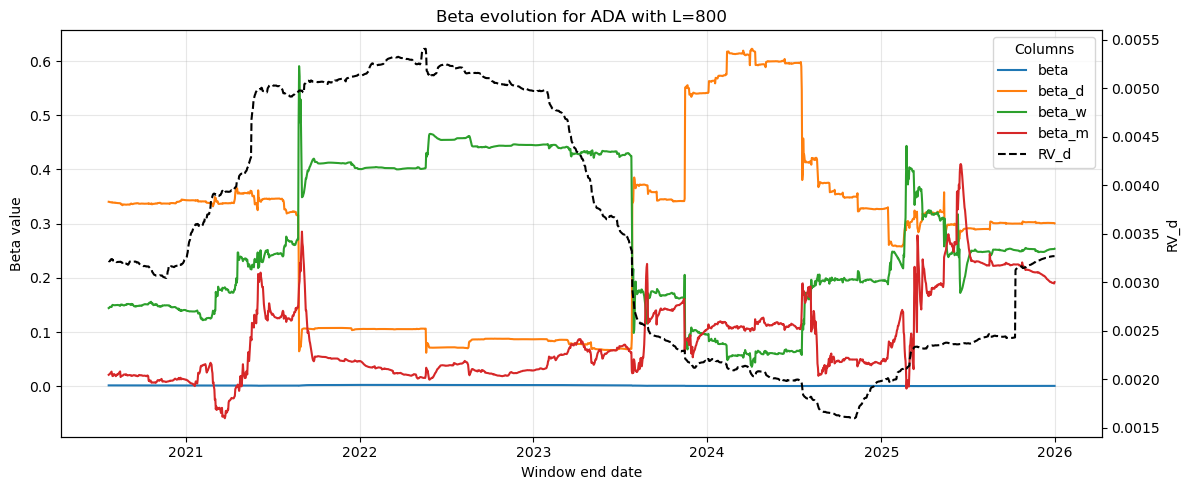

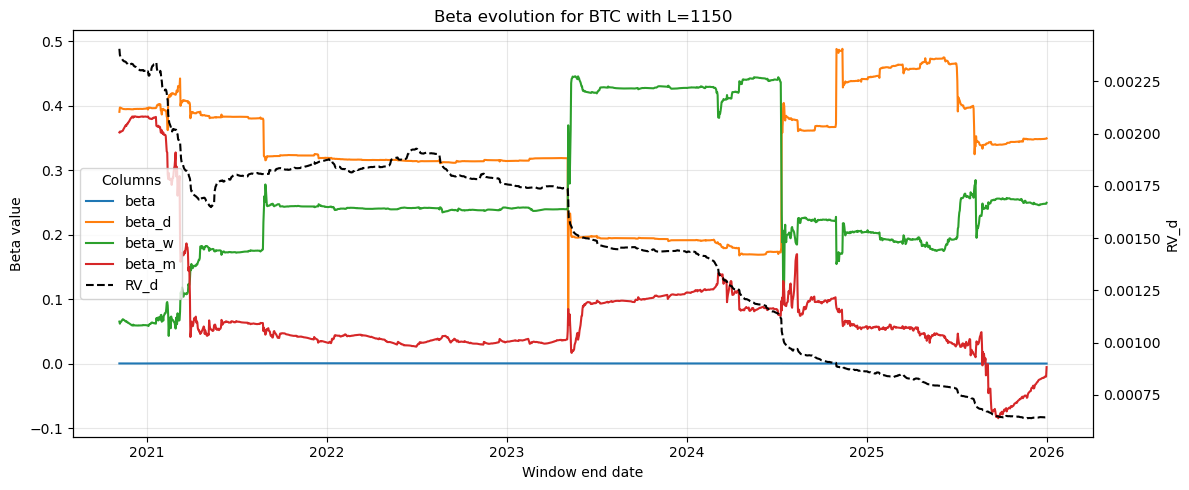

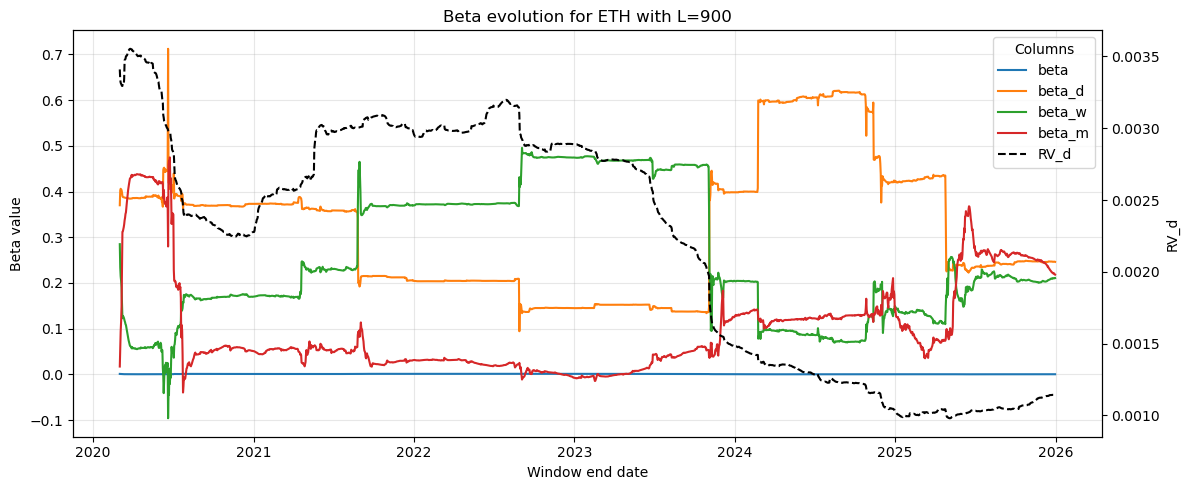

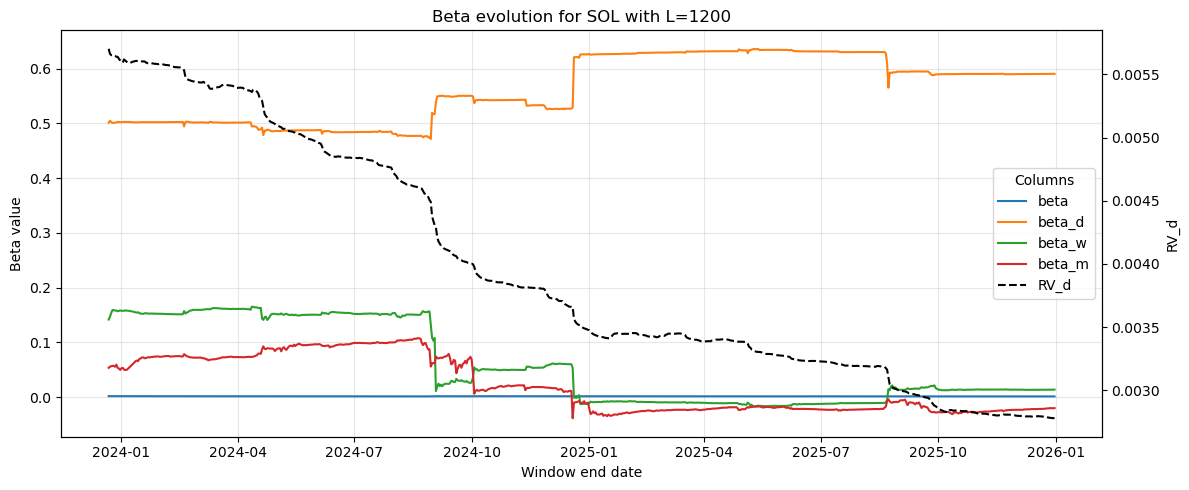

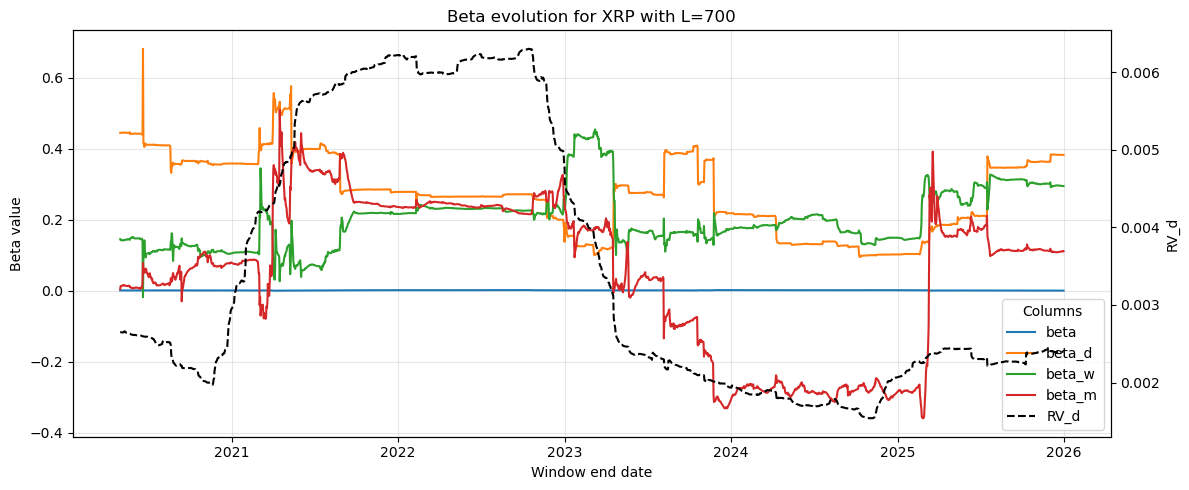

In [55]:
pair_coin_L = [("ADA", 800), ("BTC", 1150), ("ETH", 900), ("SOL", 1200), ("XRP", 700)]

for coin, L in pair_coin_L:
    coin_result_path = results_path + f"{coin}/"
    coin_data_path = data_path + f"{coin}_har.parquet"
    
    optimal_window_df = pd.read_csv(coin_result_path + "optimal_window.csv")
    coin_data_df = pd.read_parquet(coin_data_path)
    
    rolled_100_df = coin_data_df.rolling(window=L).mean().dropna()
    rolled_100_df["end_date"] = rolled_100_df.index
    rolled_100_df["end_date"] = pd.to_datetime(rolled_100_df["end_date"], utc=True, errors="coerce")
    optimal_window_df["end_date"] = pd.to_datetime(optimal_window_df["window_end_date"], utc=True, errors="coerce")
    
    merge_df = pd.merge(optimal_window_df, rolled_100_df, left_on="end_date", right_on="end_date", how="left")
    merge_df.set_index("end_date", inplace=True)
    
    ax = plot_betas(merge_df, title=f"Beta evolution for {coin} with L={L}")

,coin,window_size,window_end_date,train_loss,val_loss,beta,beta_d,beta_w,beta_m
0,ADA,300,2019-03-11 00:00:00+00:00,0.280101,0.275179,0.002027,0.407357,0.275879,-0.263277
1,ADA,300,2019-03-12 00:00:00+00:00,0.279381,0.276577,0.001987,0.406123,0.281236,-0.254038
2,ADA,300,2019-03-13 00:00:00+00:00,0.278588,0.276090,0.001953,0.401432,0.291912,-0.248473
3,ADA,300,2019-03-14 00:00:00+00:00,0.276388,0.277696,0.001913,0.397070,0.298151,-0.236235
4,ADA,300,2019-03-15 00:00:00+00:00,0.276887,0.270989,0.001809,0.393357,0.297394,-0.194343
...,...,...,...,...,...,...,...,...,...
220483,XRP,1450,2025-12-27 00:00:00+00:00,0.449759,1.105999,0.000801,0.271860,0.241908,0.110820
220484,XRP,1450,2025-12-28 00:00:00+00:00,0.450244,1.099830,0.000800,0.271815,0.242095,0.111076
220485,XRP,1450,2025-12-29 00:00:00+00:00,0.450635,1.100328,0.000798,0.271940,0.241904,0.111507
220486,XRP,1450,2025-12-30 00:00:00+00:00,0.450936,1.100013,0.000801,0.271906,0.242054,0.110764


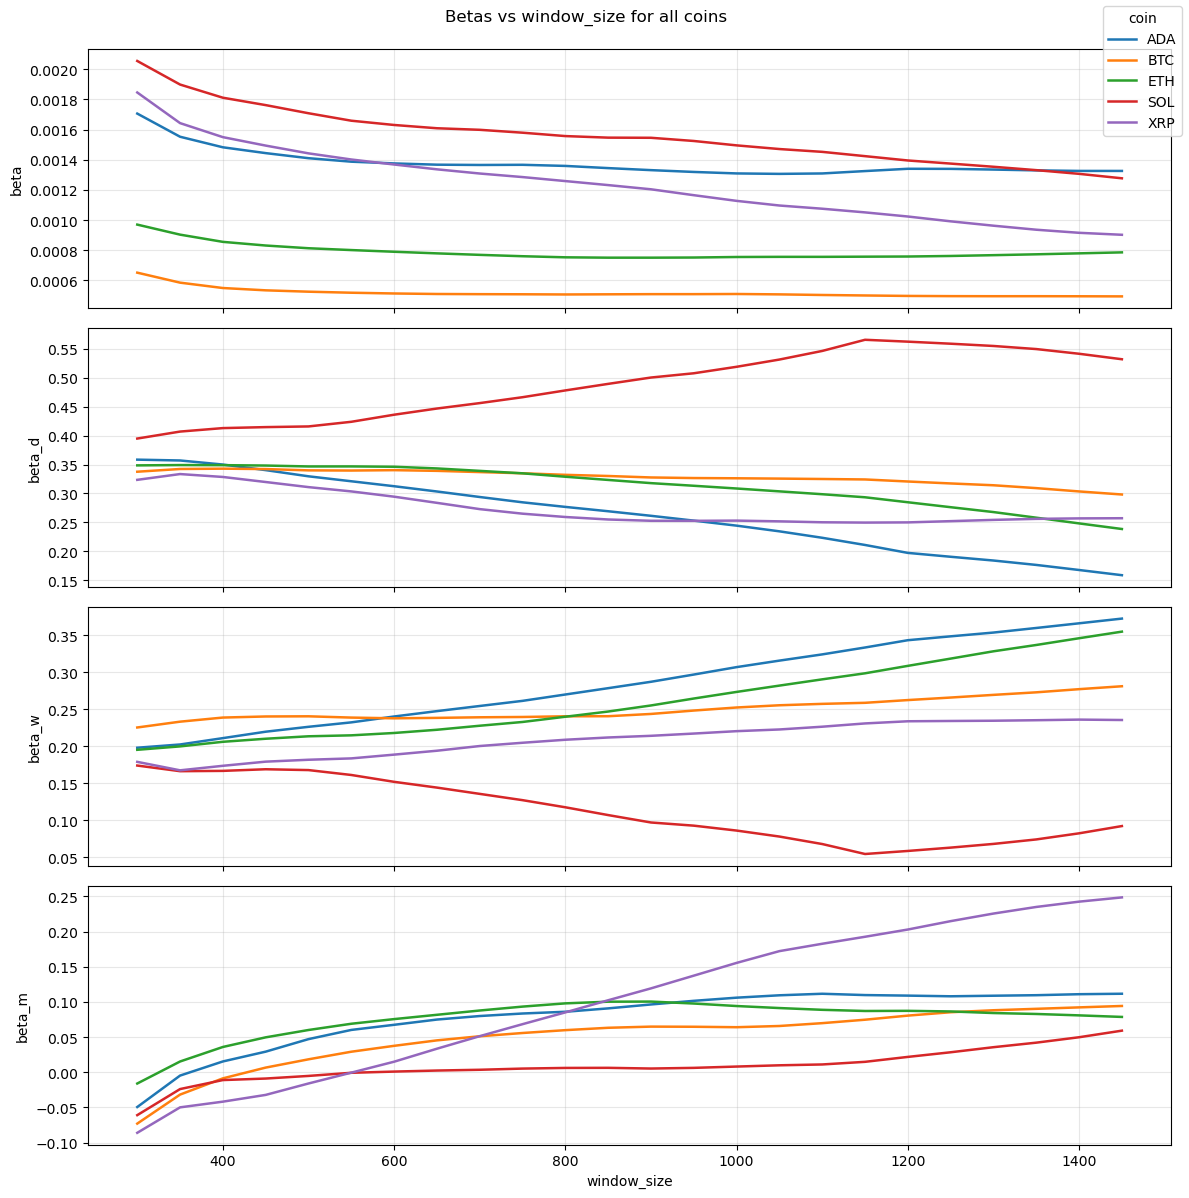

In [29]:
coin_list = ["ADA", "BTC","ETH", "SOL", "XRP"]
0
consolidate_df = pd.DataFrame()
for coin in coin_list:
    coin_result_path = results_path + f"{coin}/"
    detailed_df = pd.read_csv(coin_result_path + "detailed_results.csv")
    if consolidate_df.empty:
        consolidate_df = detailed_df
    else:
        consolidate_df = pd.concat([consolidate_df, detailed_df], ignore_index=True)
    
display(consolidate_df)
fig, axes = plot_betas_by_window_size(consolidate_df, title="Betas vs window_size for all coins")